# Load Dataset

In [126]:
import tensorflow as tf
import os
import time
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Download the 'edges2shoes' dataset instead of facades
dataset_url = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz"
path_to_zip = tf.keras.utils.get_file('edges2shoes.tar.gz', origin=dataset_url, extract=True)

# Correct PATH to dataset root
# The get_file extracts to path_to_zip (e.g., edges2shoes_extracted), and typically the content is in a subfolder with the dataset name.
PATH = os.path.join(path_to_zip, 'edges2shoes')

print(f"Dataset downloaded and extracted to: {PATH}")

TensorFlow Version: 2.19.0
Dataset downloaded and extracted to: /root/.keras/datasets/edges2shoes_extracted/edges2shoes


# Load and split

In [127]:
def load_and_split(image_file):
    # Read and decode the image
    image = tf.io.read_file(image_file)
    image = tf.io.decode_jpeg(image)

    # Split the image in half
    w = tf.shape(image)[1]
    w = w // 2

    # 🔥 IMPORTANT CHANGE HERE
    input_image = image[:, :w, :]   # edge (LEFT)
    real_image  = image[:, w:, :]   # real (RIGHT)

    # Convert to float32
    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)

    # Resize to 256x256
    input_image = tf.image.resize(input_image, [256, 256])
    real_image = tf.image.resize(real_image, [256, 256])

    # Normalize the images to [-1, 1]
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1

    return input_image, real_image

# Train Dataset

In [128]:
import os

# Create the training dataset pipeline
train_dataset = tf.data.Dataset.list_files(os.path.join(PATH, 'train', '*.jpg'))

train_dataset = train_dataset.map(load_and_split, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(400)
train_dataset = train_dataset.take(2000)
train_dataset = train_dataset.batch(1)  # ✅ YOU SHOULD ENABLE THIS for Pix2Pix

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Data pipeline ready!")

Data pipeline ready!


In [129]:
for input_image, real_image in train_dataset.take(1):
    print("Shape of input image:", input_image.shape)
    print("Shape of real image:", real_image.shape)
    print("Data type of input image:", input_image.dtype)
    print("Data type of real image:", real_image.dtype)

# To 'work on' the dataset, you would typically iterate over it in batches
# Let's re-add the batching and then show an example of fetching one batch.
# First, ensure batching is applied:
# data = train_dataset.batch(1) # Using batch size of 1 as suggested by the paper

# The train_dataset is already batched in a previous cell.
# Use the already batched train_dataset directly
data = train_dataset

# Get one batch from the batched dataset
for input_batch, real_batch in data.take(1):
    print("\nShape of input batch:", input_batch.shape)
    print("Shape of real batch:", real_batch.shape)

Shape of input image: (1, 256, 256, 3)
Shape of real image: (1, 256, 256, 3)
Data type of input image: <dtype: 'float32'>
Data type of real image: <dtype: 'float32'>

Shape of input batch: (1, 256, 256, 3)
Shape of real batch: (1, 256, 256, 3)


#

In [130]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [131]:
class CNNblock(keras.Layer):
  def __init__(self,channel,stride):
    super(CNNblock,self).__init__()
    self.conv=layers.Conv2D(channel,kernel_size=4,strides=stride,padding="same")
    self.batchnorm=layers.BatchNormalization()
    self.leakyrelu=layers.LeakyReLU(0.2)
  def call(self,input_tensor,training=False):
    x=self.conv(input_tensor)
    x=self.batchnorm(x,training=training)
    x=self.leakyrelu(x)
    return x

In [132]:
class CNNblock_drop(keras.Layer):
  def __init__(self,channel):
    super(CNNblock_drop,self).__init__()
    self.conv=layers.Conv2DTranspose(channel,kernel_size=4,strides=2,padding="same")
    self.batchnorm=layers.BatchNormalization()
    self.dropout=layers.Dropout(0.5)
    self.leakyrelu=layers.LeakyReLU(0.2)
  def call(self,input_tensor,training=False):
    x=self.conv(input_tensor)
    x=self.batchnorm(x,training=training)
    x=self.dropout(x,training=training)
    x=self.leakyrelu(x)
    return x

In [133]:
class CNNblock_trans(keras.Layer):
  def __init__(self,channel):
    super(CNNblock_trans,self).__init__()
    self.conv=layers.Conv2DTranspose(channel,kernel_size=4,strides=2,padding="same")
    self.batchnorm=layers.BatchNormalization()
    self.leakyrelu=layers.LeakyReLU(0.2)
  def call(self,input_tensor,training=False):
    x=self.conv(input_tensor)
    x=self.batchnorm(x,training=training)
    x=self.leakyrelu(x)
    return x

# Generator

In [134]:
class Generator(keras.Model):

  def __init__(self):
    super(Generator,self).__init__()

    initializer = tf.random_normal_initializer(0., 0.02)
    self.initial_conv = layers.Conv2D(64,kernel_size=4,strides=2,padding="same",kernel_initializer=initializer)
    self.initial_leaky_relu =layers.LeakyReLU(0.2)

    self.cnn_block_128 = CNNblock(128,2)
    self.cnn_block_256 = CNNblock(256,2)
    self.cnn_block_512_1 = CNNblock(512,2)
    self.cnn_block_512_2 = CNNblock(512,2)
    self.cnn_block_512_3 = CNNblock(512,2)
    self.cnn_block_512_4 = CNNblock(512,2)

    self.bottleneck_conv = layers.Conv2D(512,kernel_size=4,strides=2,padding="same")
    self.bottleneck_leaky_relu =layers.LeakyReLU(0.2)

    self.cnn_block_drop_512_1 = CNNblock_drop(512)
    self.cnn_block_drop_512_2 = CNNblock_drop(512)
    self.cnn_block_drop_512_3 = CNNblock_drop(512)

    self.cnn_block_trans_512 = CNNblock_trans(512)
    self.cnn_block_trans_256 = CNNblock_trans(256)
    self.cnn_block_trans_128 = CNNblock_trans(128)
    self.cnn_block_trans_64 = CNNblock_trans(64)

    self.final_conv_transpose = layers.Conv2DTranspose(3,kernel_size=4,strides=2,padding="same")
    self.final_activation = layers.Activation("tanh")

  def call(self, input_tensor,training=False):

    e1_conv_out = self.initial_conv(input_tensor)
    e1 = self.initial_leaky_relu(e1_conv_out)

    e2 = self.cnn_block_128(e1,training=training)
    e3 = self.cnn_block_256(e2,training=training)

    e4 = self.cnn_block_512_1(e3,training=training)
    e5 = self.cnn_block_512_2(e4,training=training)
    e6 = self.cnn_block_512_3(e5,training=training)
    e7 = self.cnn_block_512_4(e6,training=training)


    bottleneck_conv_out = self.bottleneck_conv(e7)
    bottleneck_out = self.bottleneck_leaky_relu(bottleneck_conv_out)


    d1 = self.cnn_block_drop_512_1(bottleneck_out,training=training)
    d1 = tf.concat([d1,e7], axis=-1)

    d2 = self.cnn_block_drop_512_2(d1,training=training)
    d2 = tf.concat([d2,e6], axis=-1)

    d3 = self.cnn_block_drop_512_3(d2,training=training)
    d3 = tf.concat([d3,e5], axis=-1)

    d4 = self.cnn_block_trans_512(d3,training=training)
    d4 = tf.concat([d4,e4], axis=-1)

    d5 = self.cnn_block_trans_256(d4,training=training)
    d5 = tf.concat([d5,e3], axis=-1)

    d6 = self.cnn_block_trans_128(d5,training=training)
    d6 = tf.concat([d6,e2], axis=-1)

    d7 = self.cnn_block_trans_64(d6,training=training)
    d7 = tf.concat([d7,e1], axis=-1)

    final_conv_transpose_out = self.final_conv_transpose(d7)
    output = self.final_activation(final_conv_transpose_out)

    return output

In [135]:
Generator = Generator()
input=tf.random.normal(shape=(1,256,256,3))
output=Generator(input)
Generator.summary()

Model: "generator_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_65 (Conv2D)              │ (1, 128, 128, 64)      │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_95 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_45 (CNNblock)         │ ?                      │       131,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_46 (CNNblock)         │ ?                      │       525,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_47 (CNNblock)         │ ?                      │     2,099,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_48 (CNNblock)         │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_49 (CNNblock)         │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_50 (CNNblock)         │ ?                      │     4,196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (1, 1, 1, 512)         │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_102 (LeakyReLU)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_drop_15               │ ?                      │     4,196,864 │
│ (CNNblock_drop)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_drop_16               │ ?                      │     8,391,168 │
│ (CNNblock_drop)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_drop_17               │ ?                      │     8,391,168 │
│ (CNNblock_drop)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_20              │ ?                      │     8,391,168 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_21              │ ?                      │     4,195,584 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_22              │ ?                      │     1,049,216 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_trans_23              │ ?                      │       262,464 │
│ (CNNblock_trans)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_47             │ (1, 256, 256, 3)       │         6,147 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,429,315 (207.63 MB)

 Trainable params: 54,419,459 (207.59 MB)

 Non-trainable params: 9,856 (38.50 KB)

# Discriminator

In [136]:
class Discriminator(keras.Model):
  def __init__(self):
    super(Discriminator,self).__init__()
    initializer = tf.random_normal_initializer(0., 0.02)
    self.initial_conv=layers.Conv2D(64,kernel_size=4,strides=2,padding="same",kernel_initializer=initializer)
    self.initial_leaky_relu=layers.LeakyReLU(0.2)
    self.lay1=CNNblock(128,2)
    self.lay2=CNNblock(256,2)
    self.lay3=CNNblock(512,2)
    self.out_lay=layers.Conv2D(1,kernel_size=4,strides=1,padding="valid")
  def call(self,input,training=False):
    x=self.initial_conv(input)
    x=self.initial_leaky_relu(x)
    x=self.lay1(x,training=training)
    x=self.lay2(x,training=training)
    x=self.lay3(x,training=training)
    x=self.out_lay(x)
    return x

In [137]:
Discriminator=Discriminator()
input=tf.random.normal(shape=(1,256,256,6))
output=Discriminator(input)
Discriminator.summary()

Model: "discriminator_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_73 (Conv2D)              │ (1, 128, 128, 64)      │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_110 (LeakyReLU)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_51 (CNNblock)         │ ?                      │       131,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_52 (CNNblock)         │ ?                      │       525,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cn_nblock_53 (CNNblock)         │ ?                      │     2,099,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (1, 13, 13, 1)         │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,771,393 (10.57 MB)

 Trainable params: 2,769,601 (10.57 MB)

 Non-trainable params: 1,792 (7.00 KB)

# Loss

In [138]:
cross_entropy=keras.losses.BinaryCrossentropy(from_logits=True)

In [139]:
def Discriminator_loss(real_output,fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output)*0.9,real_output)
  fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
  total_loss=fake_loss+real_loss
  return total_loss

In [140]:
def Generator_loss(fake_output,fake,real):
  c=100
  loss=cross_entropy(tf.ones_like(fake_output),fake_output)+c*tf.reduce_mean(tf.abs(real-fake))
  return loss



# Optimizers

In [141]:

optimizer1=tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5,
    beta_2=0.999
)

optimizer2=tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5,
    beta_2=0.999
)

# Concate 2 tensors

In [142]:
from tensorflow.keras.layers import Concatenate
def concat(image,label):
  return tf.concat([image, label], axis=-1)

# Training Loop

In [143]:
@tf.function
def training_loop(image_x,image_y, is_training):


  with tf.GradientTape() as gen_tape,tf.GradientTape() as disc_tape:

    image_gen=Generator(image_x,training=is_training)
    real_image=concat(image_x,image_y)
    fake_image=concat(image_x,image_gen)
    real_output=Discriminator(real_image,training=is_training)
    fake_output=Discriminator(tf.stop_gradient(fake_image),training=is_training)

    disc_loss=Discriminator_loss(real_output,fake_output)

    fake_output2=Discriminator(fake_image,training=is_training)
    gen_loss=Generator_loss(fake_output2,image_gen,image_y)

  disc_gradients=disc_tape.gradient(disc_loss,Discriminator.trainable_variables)
  gen_gradients=gen_tape.gradient(gen_loss,Generator.trainable_variables)

  optimizer1.apply_gradients(zip(disc_gradients,Discriminator.trainable_variables))
  optimizer2.apply_gradients(zip(gen_gradients,Generator.trainable_variables))

  return gen_loss, disc_loss

# Load TestData

In [144]:
test_dataset = tf.data.Dataset.list_files(os.path.join(PATH, 'val', '*.jpg'))

test_dataset = test_dataset.map(load_and_split, num_parallel_calls=tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(1)  # keep this

print("Test data pipeline ready!")

Test data pipeline ready!


# Train Model

In [145]:
for example_x, example_y in test_dataset.take(3):
    fixed_x, fixed_y = example_x, example_y


def train(epochs):
    steps_per_epoch = tf.data.experimental.cardinality(data).numpy()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Initialize Keras progress bar
        progbar = tf.keras.utils.Progbar(steps_per_epoch)

        for step, (image_x, image_y) in enumerate(data):
            g_loss, d_loss = training_loop(image_x, image_y, is_training=True)

            # Update bar with current losses
            progbar.update(step + 1, values=[("gen_loss", g_loss), ("disc_loss", d_loss)])

        # Every epoch (or every 5), show the model's progress
        if (epoch + 1) % 2 == 0:
            generate_and_plot(fixed_x, fixed_y)

from IPython import display # Add this import at the top

def generate_and_plot(test_input, target):
    prediction = Generator(test_input, training=False)

    # This line clears the previous plots so they don't stack vertically
    display.clear_output(wait=True)

    plt.figure(figsize=(12, 4))
    display_list = [test_input[0], target[0], prediction[0]]
    titles = ['Input', 'Target', 'Generated']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')

    plt.show()
    # Adding a small pause helps Kaggle's renderer
    plt.pause(0.1)

# Generate & save Generator

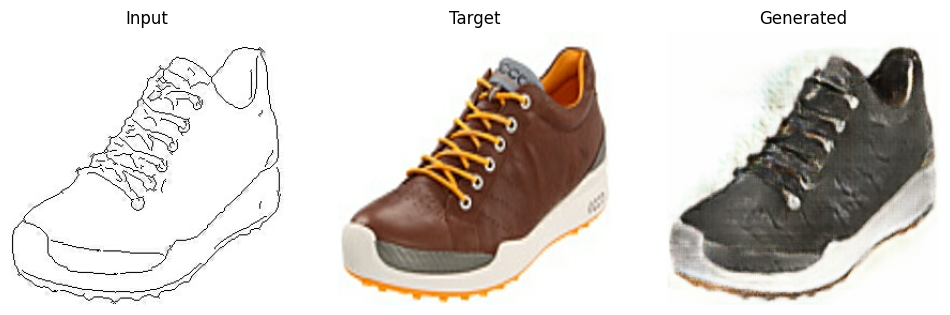


Epoch 43/100
1265/2000 ━━━━━━━━━━━━━━━━━━━━ 1:28 120ms/step - gen_loss: 15.6427 - disc_loss: 0.7759

In [ ]:
train(100)
Generator.save("Generator.keras")

In [1]:
for example_x, example_y in test_dataset.take(10):
    fixed_x, fixed_y = example_x, example_y
    generate_and_plot(fixed_x, fixed_y)

NameError: name 'test_dataset' is not defined